# 03 — Análise Exploratória pré-TCC 2

Exploração dos dados transformados para embasar as escolhas metodológicas dos modelos do TCC 2 (GAM, BSTS, Causal Forest). Inclui diagnóstico do tratamento para Causal Forests.

| | |
|---|---|
| **Entradas** | `data/br_transformado.csv` |
| **Saídas** | Resultados exploratórios (sem modelo; sem registro de métricas) |
| **Ordem** | 3º — depois do notebook 02; antes dos notebooks de modelo |


In [1]:
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
from tcc_utils import *


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_ljungbox

# Carrega dados e split
br_transformado = load_transformado()
train, test = split_treino_teste(br_transformado)
print(f"br_transformado: {br_transformado.shape} | treino: {train.shape} | teste: {test.shape}")


br_transformado: (5598, 7) | treino: (4481, 7) | teste: (1117, 7)


# Análise Exploratória dos Dados (pré-TCC 2)

## Estatísticas Descritivas, Escala e Variância

In [3]:
# EDA — Estatísticas descritivas, escala e variância
import numpy as np
import pandas as pd

eda_features = [col for col in br_transformado.columns if "ibov" not in col]
eda_target   = "br_ibov_ret_log"

print("=" * 70)
print("ESTATÍSTICAS DESCRITIVAS — br_transformado (série completa)")
print("=" * 70)
display(br_transformado.describe().T.round(6))

# Desvio-padrão, coef. de variação e % de zeros por feature
eda_stats = pd.DataFrame({
    "Desvio Padrão":    br_transformado[eda_features].std(),
    "Coef. Variação":   (br_transformado[eda_features].std()
                         / br_transformado[eda_features].mean().abs()
                        ).replace([np.inf, -np.inf], np.nan).round(2),
    "% Zeros":          (br_transformado[eda_features] == 0).mean().mul(100).round(1),
}).sort_values("Desvio Padrão", ascending=False)
print("\n--- Escala, Variância e Esparsidade por Variável ---")
print("(% Zeros alta sinaliza baixa variabilidade efetiva)")
display(eda_stats.round(4))

# Comparativo treino vs teste: média ± desvio por variável
print("\n--- Comparativo Treino vs Teste: Média ± DP por Variável ---")
eda_comp_rows = []
for col in [eda_target] + eda_features:
    eda_comp_rows.append({
        "Variável":       col,
        "Treino (média)": train[col].mean(),
        "Treino (dp)":    train[col].std(),
        "Teste  (média)": test[col].mean(),
        "Teste  (dp)":    test[col].std(),
        "Δ média":        test[col].mean() - train[col].mean(),
    })
display(pd.DataFrame(eda_comp_rows).set_index("Variável").round(6))
print("Δ média relevante sinaliza não-estacionariedade entre os períodos.")


ESTATÍSTICAS DESCRITIVAS — br_transformado (série completa)


,count,mean,std,min,25%,50%,75%,max
br_ibov_ret_log,5598.0,0.000414,0.017132,-0.159930,-0.008473,0.000744,0.009952,0.154728
br_selic_diff,5598.0,-0.000005,0.000429,-0.007684,0.000000,0.000000,0.000000,0.009978
br_dolar_diff,5598.0,0.000545,0.033610,-0.297300,-0.013400,-0.000400,0.013700,0.273100
br_ipca,5598.0,0.495735,0.372079,-0.680000,0.270968,0.455484,0.670000,3.020000
br_pib_ret_log,5598.0,0.000384,0.002284,-0.012409,-0.000621,0.000170,0.001231,0.021638
ipca_expectativa_diff,5598.0,-0.000023,0.017644,-0.220000,0.000000,0.000000,0.000000,0.320000
embi_brasil_diff,5598.0,-0.159879,17.361154,-247.000000,-4.000000,0.000000,4.000000,246.000000



--- Escala, Variância e Esparsidade por Variável ---
(% Zeros alta sinaliza baixa variabilidade efetiva)


,Desvio Padrão,Coef. Variação,% Zeros
embi_brasil_diff,17.3612,108.59,9.6
br_ipca,0.3721,0.75,0.1
br_dolar_diff,0.0336,61.63,0.2
ipca_expectativa_diff,0.0176,772.85,67.5
br_pib_ret_log,0.0023,5.95,0.0
br_selic_diff,0.0004,80.24,87.1



--- Comparativo Treino vs Teste: Média ± DP por Variável ---


,Treino (média),Treino (dp),Teste (média),Teste (dp),Δ média
Variável,,,,,
br_ibov_ret_log,0.000499,0.017137,0.000075,0.017113,-0.000423
br_selic_diff,-0.000012,0.000426,0.000020,0.000441,0.000031
br_dolar_diff,0.000319,0.027453,0.001453,0.051370,0.001133
br_ipca,0.497127,0.359936,0.490150,0.417386,-0.006977
br_pib_ret_log,0.000371,0.002228,0.000438,0.002497,0.000067
ipca_expectativa_diff,0.000011,0.017189,-0.000159,0.019369,-0.000170
embi_brasil_diff,-0.202633,19.009866,0.011638,7.805249,0.214272


Δ média relevante sinaliza não-estacionariedade entre os períodos.


## Correlação com o Alvo e Multicolinearidade

CORRELAÇÃO DAS FEATURES COM O ALVO


,Pearson,Spearman,Spearman p-val
Feature,,,
embi_brasil_diff,-0.4039,-0.4393,0.0000
br_dolar_diff,-0.3394,-0.3168,0.0000
ipca_expectativa_diff,0.0139,-0.0033,0.8036
br_pib_ret_log,0.0119,-0.0141,0.2916
br_ipca,-0.0014,-0.0153,0.2526
br_selic_diff,0.0004,-0.0122,0.3604


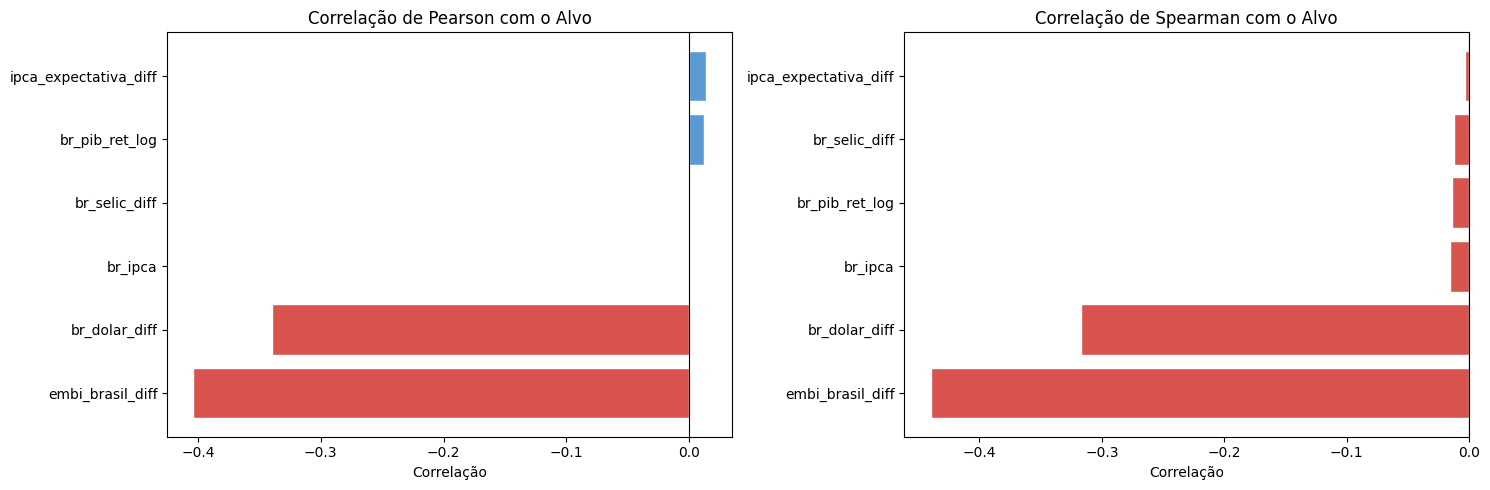

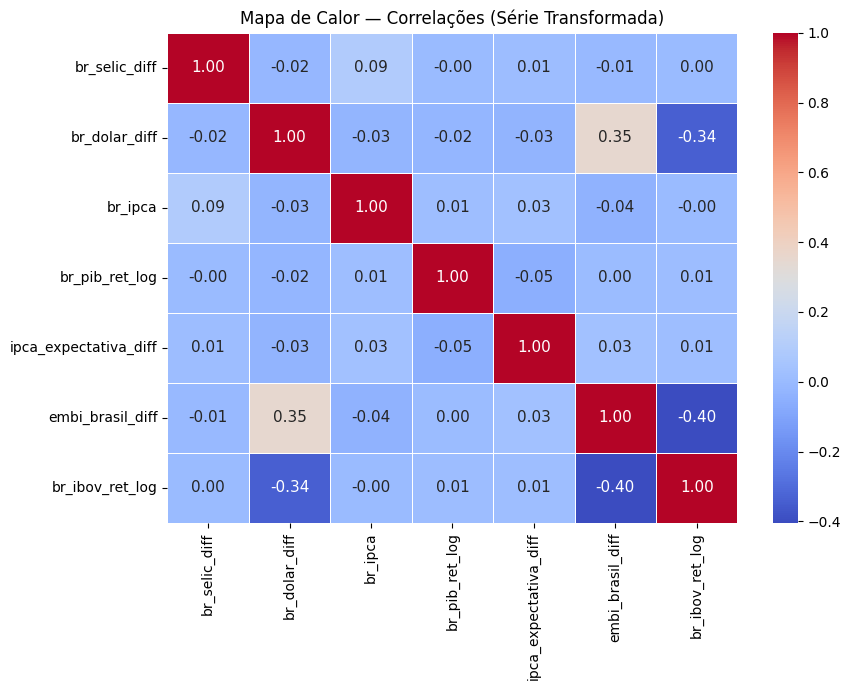


--- VIF das Features (Multicolinearidade) ---


,VIF
Feature,
embi_brasil_diff,1.14
br_dolar_diff,1.14
br_ipca,1.02
br_pib_ret_log,1.02
ipca_expectativa_diff,1.01
br_selic_diff,1.00


Referência: VIF > 5 moderado | VIF > 10 severo.


In [4]:
# EDA — Correlação das features com o alvo e multicolinearidade (VIF)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor

eda_features = [col for col in br_transformado.columns if "ibov" not in col]
eda_target   = "br_ibov_ret_log"

# Pearson e Spearman de cada feature com o alvo
eda_corr_rows = []
for col in eda_features:
    p = br_transformado[col].corr(br_transformado[eda_target])
    s, sp = spearmanr(br_transformado[col], br_transformado[eda_target])
    eda_corr_rows.append({"Feature": col, "Pearson": p, "Spearman": s, "Spearman p-val": sp})
eda_corr_df = pd.DataFrame(eda_corr_rows).set_index("Feature")
print("=" * 70)
print("CORRELAÇÃO DAS FEATURES COM O ALVO")
print("=" * 70)
display(eda_corr_df.sort_values("Pearson", key=abs, ascending=False).round(4))

# Gráfico barras: Pearson e Spearman
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metrica in zip(axes, ["Pearson", "Spearman"]):
    eda_ord = eda_corr_df[metrica].sort_values()
    colors = ["#d9534f" if v < 0 else "#5b9bd5" for v in eda_ord]
    ax.barh(eda_ord.index, eda_ord.values, color=colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Correlação de {metrica} com o Alvo")
    ax.set_xlabel("Correlação")
plt.tight_layout()
plt.show()

# Heatmap feature×feature (roda em ambos os modos; cél. 29 só roda em modo completo)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    br_transformado[eda_features + [eda_target]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    annot_kws={"size": 11}, linewidths=0.5, ax=ax
)
ax.set_title("Mapa de Calor — Correlações (Série Transformada)")
plt.tight_layout()
plt.show()

# VIF das 6 features
print("\n--- VIF das Features (Multicolinearidade) ---")
eda_X_vif = br_transformado[eda_features].dropna().values
eda_vif = pd.DataFrame({
    "Feature": eda_features,
    "VIF":     [variance_inflation_factor(eda_X_vif, i) for i in range(len(eda_features))],
}).set_index("Feature").sort_values("VIF", ascending=False)
display(eda_vif.round(2))
print("Referência: VIF > 5 moderado | VIF > 10 severo.")


## Estrutura Temporal: Autocorrelação e Defasagens

AUTOCORRELAÇÃO DO ALVO (br_ibov_ret_log)


,"Corr(ibov_t, ibov_{t-lag})"
Lag,
1,-0.0490
2,0.0056
5,0.0143
10,0.0350



Teste Ljung-Box sobre o alvo (não sobre resíduos):


,lb_stat,lb_pvalue
5,20.6029,0.001
10,43.8169,0.000
20,54.7419,0.000


p < 0.05 (rejeita H0): há autocorrelação residual significativa nos retornos,
embora fraca em magnitude — estrutura temporal existe e justifica modelos como BSTS.

--- Correlação das Regressoras Defasadas com o Retorno do Dia Seguinte ---


Lag,Lag 1,Lag 2,Lag 5,Contemp.
Feature,,,,
br_dolar_diff,0.0346,-0.0425,0.0023,-0.3394
br_ipca,-0.0022,-0.0031,-0.0055,-0.0014
br_pib_ret_log,-0.0047,0.0156,0.0089,0.0119
br_selic_diff,0.0018,0.0244,0.0071,0.0004
embi_brasil_diff,-0.0264,-0.0157,0.0054,-0.4039
ipca_expectativa_diff,0.0013,0.0046,0.0090,0.0139


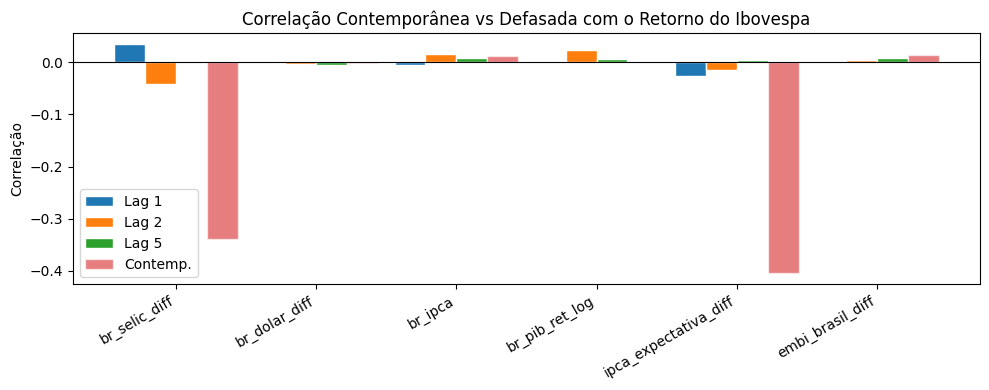

Lag > Contemp. sugere que a versão defasada da variável prediz melhor o retorno.


In [5]:
# EDA — Autocorrelação do alvo e correlação com regressoras defasadas
# Complementa ACF/PACF da cél. 32; foca em lags curtos e regressoras defasadas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

eda_features = [col for col in br_transformado.columns if "ibov" not in col]
eda_target   = "br_ibov_ret_log"
eda_y        = br_transformado[eda_target].dropna()

# Autocorrelação do alvo (lags 1, 2, 5, 10)
print("=" * 70)
print("AUTOCORRELAÇÃO DO ALVO (br_ibov_ret_log)")
print("=" * 70)
eda_auto_rows = [
    {"Lag": lag, "Corr(ibov_t, ibov_{t-lag})": eda_y.corr(eda_y.shift(lag))}
    for lag in [1, 2, 5, 10]
]
display(pd.DataFrame(eda_auto_rows).set_index("Lag").round(4))

# Ljung-Box sobre o alvo em si (não sobre resíduos de modelo)
print("\nTeste Ljung-Box sobre o alvo (não sobre resíduos):")
eda_lb = acorr_ljungbox(eda_y, lags=[5, 10, 20], return_df=True)
display(eda_lb.round(4))
print("p < 0.05 (rejeita H0): há autocorrelação residual significativa nos retornos,")
print("embora fraca em magnitude — estrutura temporal existe e justifica modelos como BSTS.")

# Correlação de cada regressora defasada vs retorno do dia seguinte
print("\n--- Correlação das Regressoras Defasadas com o Retorno do Dia Seguinte ---")
eda_lag_rows = []
for col in eda_features:
    x = br_transformado[col]
    r0 = x.corr(eda_y)
    for lag in [1, 2, 5]:
        eda_lag_rows.append({
            "Feature": col,
            "Lag":     lag,
            "Corr defasada": x.shift(lag).corr(eda_y),
            "Corr contemp.": r0,
        })
eda_lag_df = pd.DataFrame(eda_lag_rows)
eda_lag_pivot = (
    eda_lag_df.pivot(index="Feature", columns="Lag", values="Corr defasada")
    .rename(columns=lambda c: f"Lag {c}")
)
eda_lag_pivot["Contemp."] = (
    eda_lag_df[eda_lag_df["Lag"] == 1].set_index("Feature")["Corr contemp."]
)
display(eda_lag_pivot.round(4))

# Destaque: autocorrelação do alvo para motivar ibov_lag1 no BSTS
fig, ax = plt.subplots(figsize=(10, 4))
eda_lag_cols = [f"Lag {l}" for l in [1, 2, 5]]
x_pos = range(len(eda_features))
width = 0.22
for i, col in enumerate(eda_lag_cols):
    ax.bar(
        [p + i * width for p in x_pos],
        eda_lag_pivot[col].values,
        width=width, label=col, edgecolor="white"
    )
ax.bar(
    [p + 3 * width for p in x_pos],
    eda_lag_pivot["Contemp."].values,
    width=width, label="Contemp.", edgecolor="white", alpha=0.6
)
ax.set_xticks([p + 1.5 * width for p in x_pos])
ax.set_xticklabels(eda_features, rotation=30, ha="right")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Correlação Contemporânea vs Defasada com o Retorno do Ibovespa")
ax.set_ylabel("Correlação")
ax.legend()
plt.tight_layout()
plt.show()
print("Lag > Contemp. sugere que a versão defasada da variável prediz melhor o retorno.")


## Diagnóstico do Tratamento para Causal Forests

DIAGNÓSTICO DO TRATAMENTO T_choque_dolar
Limiar (p75 |br_dolar_diff| no treino): 0.0229
Prevalência T=1 — Treino: 25.0%  (1122 dias de 4481)
Prevalência T=1 — Teste:  55.9%  (624 dias de 1117)
↑ Desbalanceamento reflete maior volatilidade cambial pós-2020 (COVID, ciclo de juros).


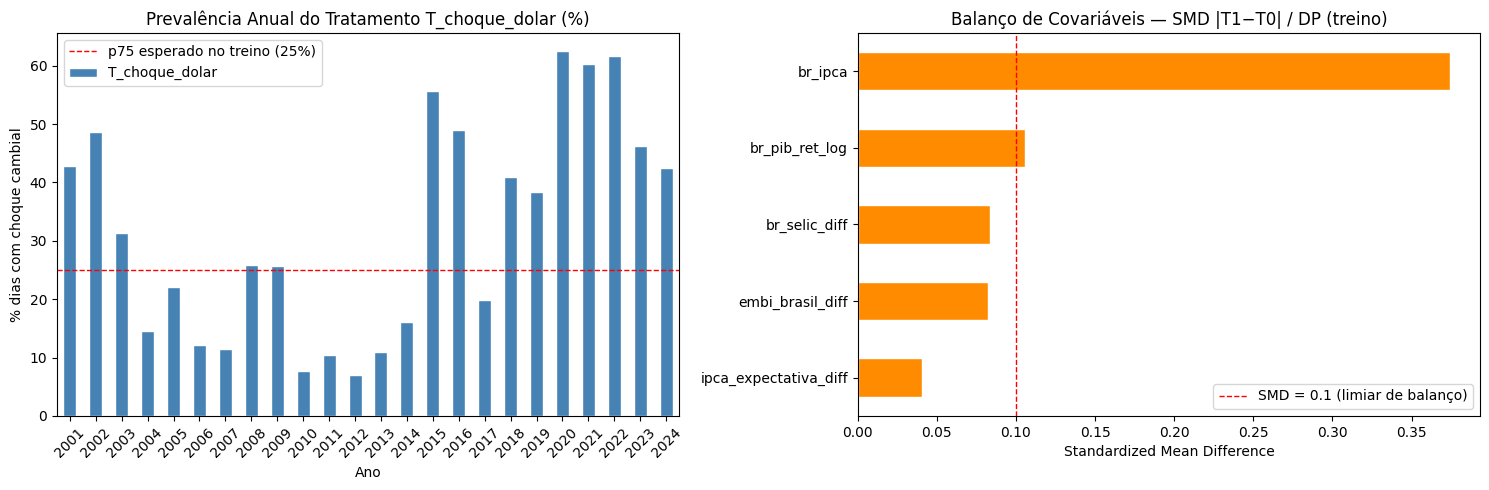


--- Médias das Covariáveis por Grupo de Tratamento (treino) ---


,T=0 (sem choque),T=1 (choque cambial),SMD
br_selic_diff,-0.00002,0.00001,0.08328
br_ipca,0.46337,0.59818,0.37455
br_pib_ret_log,0.00043,0.00019,0.10572
ipca_expectativa_diff,-0.00016,0.00053,0.04064
embi_brasil_diff,-0.59303,0.96613,0.08202



--- Retorno Médio do Ibovespa por Grupo (treino) ---
  T=0: 0.00074
  T=1: -0.00021

Nota: br_dolar_diff é EXCLUÍDA das covariáveis X do CausalForestDML (cél. 83/85)
pois T é função determinística dela — incluí-la introduziria vazamento.


In [6]:
# EDA — Diagnóstico do tratamento T_choque_dolar (para Causal Forests)
# Reconstrói o tratamento idêntico à cél. 83 (limiar p75 só no treino)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

eda_target = "br_ibov_ret_log"
eda_treat  = "T_choque_dolar"

eda_br_cf        = br_transformado.copy()
eda_mask_train   = eda_br_cf.index < DATA_SPLIT_DATE
eda_limiar_dolar = eda_br_cf.loc[eda_mask_train, "br_dolar_diff"].abs().quantile(0.75)
eda_br_cf[eda_treat] = (eda_br_cf["br_dolar_diff"].abs() >= eda_limiar_dolar).astype(int)
eda_train_cf = eda_br_cf[eda_mask_train]
eda_test_cf  = eda_br_cf[~eda_mask_train]

print("=" * 70)
print("DIAGNÓSTICO DO TRATAMENTO T_choque_dolar")
print("=" * 70)
print(f"Limiar (p75 |br_dolar_diff| no treino): {eda_limiar_dolar:.4f}")
print(f"Prevalência T=1 — Treino: {eda_train_cf[eda_treat].mean()*100:.1f}%"
      f"  ({int(eda_train_cf[eda_treat].sum())} dias de {len(eda_train_cf)})")
print(f"Prevalência T=1 — Teste:  {eda_test_cf[eda_treat].mean()*100:.1f}%"
      f"  ({int(eda_test_cf[eda_treat].sum())} dias de {len(eda_test_cf)})")
print("↑ Desbalanceamento reflete maior volatilidade cambial pós-2020 (COVID, ciclo de juros).")

# Prevalência anual
eda_yearly = eda_br_cf.groupby(eda_br_cf.index.year)[eda_treat].mean().mul(100)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

eda_yearly.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axhline(25, color="red", linestyle="--", linewidth=1,
                label="p75 esperado no treino (25%)")
axes[0].set_title("Prevalência Anual do Tratamento T_choque_dolar (%)")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("% dias com choque cambial")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

# Standardized Mean Difference das covariáveis (balanço T=0 vs T=1)
eda_covs = [c for c in eda_br_cf.columns
            if c not in [eda_target, eda_treat, "br_dolar_diff"]]
eda_t0 = eda_train_cf[eda_train_cf[eda_treat] == 0][eda_covs]
eda_t1 = eda_train_cf[eda_train_cf[eda_treat] == 1][eda_covs]
eda_smd = ((eda_t1.mean() - eda_t0.mean()) / eda_train_cf[eda_covs].std()).abs()
eda_smd.sort_values().plot(kind="barh", ax=axes[1],
                           color="darkorange", edgecolor="white")
axes[1].axvline(0.1, color="red", linestyle="--", linewidth=1,
                label="SMD = 0.1 (limiar de balanço)")
axes[1].set_title("Balanço de Covariáveis — SMD |T1−T0| / DP (treino)")
axes[1].set_xlabel("Standardized Mean Difference")
axes[1].legend()
plt.tight_layout()
plt.show()

# Médias por grupo e outcome médio
print("\n--- Médias das Covariáveis por Grupo de Tratamento (treino) ---")
eda_bal = pd.DataFrame({
    "T=0 (sem choque)":   eda_t0.mean(),
    "T=1 (choque cambial)": eda_t1.mean(),
    "SMD":                  eda_smd,
})
display(eda_bal.round(5))

print("\n--- Retorno Médio do Ibovespa por Grupo (treino) ---")
print(f"  T=0: {eda_t0.assign(y=eda_train_cf[eda_target])['y'].mean():.5f}")
print(f"  T=1: {eda_t1.assign(y=eda_train_cf[eda_target])['y'].mean():.5f}")

print("\nNota: br_dolar_diff é EXCLUÍDA das covariáveis X do CausalForestDML (cél. 83/85)")
print("pois T é função determinística dela — incluí-la introduziria vazamento.")
